# PD Scorecard and Independent Model Validation

A Weight-of-Evidence credit scorecard, then an independent validation of it (discrimination, calibration, stability, benchmarking, segments), the way a second line of defence challenges a first-line model. This notebook runs the full pipeline and embeds the results and figures.

**Data:** the cleaned Lending Club loan book (publicly available). See `VALIDATION_REPORT.md` for the formal validation write-up and `results.json` for all metrics.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, json, os
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve

PARQUET="/home/claude/fin2/data/lending_affordability.parquet"
OUT="/home/claude/scorecard"; FIG=f"{OUT}/figures"; DAT=f"{OUT}/data"
os.makedirs(FIG,exist_ok=True); os.makedirs(DAT,exist_ok=True)
NAVY="#16314E"; TEAL="#1C8C7D"; AMBER="#C8862B"; RED="#B23A48"; SLATE="#5B6B7B"; GREEN="#2E7D5B"; GREY="#9AA7B5"
plt.rcParams.update({"font.family":"DejaVu Sans","axes.edgecolor":GREY,"axes.linewidth":0.8,"axes.grid":True,
    "grid.color":"#E6ECF2","grid.linewidth":0.7,"axes.axisbelow":True,"figure.dpi":120})
EPS=1e-6

df=pd.read_parquet(PARQUET)
NUM=['fico','dti_eff','payment_to_income','loan_to_income','annual_inc_eff','installment','loan_amnt',
     'emp_length_num','revol_util','delinq_2yrs','inq_last_6mths','open_acc','pub_rec','total_acc','credit_history_yrs']
CAT=['term_months','home_ownership','purpose','verification_status']
for c in NUM: df[c]=pd.to_numeric(df[c],errors='coerce')
df['target']=df['default'].astype(int)
dev=df[df['issue_year']<=2015].copy(); oot=df[df['issue_year']>=2016].copy()
print(f"Development (<=2015): {len(dev):,}  Out-of-time (>=2016): {len(oot):,}  bad rate dev {dev.target.mean():.3f}")

Development (<=2015): 829,350  Out-of-time (>=2016): 518,744  bad rate dev 0.185


### WoE encoder

In [2]:
class WoE:
    def __init__(self,nbins=6): self.nbins=nbins; self.maps={}; self.iv={}; self.edges={}; self.catmap={}
    def fit(self,X,y):
        for c in NUM:
            s=X[c]; q=pd.qcut(s,self.nbins,duplicates='drop')
            edges=[-np.inf]+list(pd.IntervalIndex(q.cat.categories).right[:-1])+[np.inf]
            self.edges[c]=edges
            b=pd.cut(s,bins=edges); b=b.cat.add_categories(['Missing']).fillna('Missing')
            self._woe(c,b,y)
        for c in CAT:
            s=X[c].astype(str).fillna('Missing')
            vc=s.value_counts(normalize=True); rare=vc[vc<0.01].index
            s=s.where(~s.isin(rare),'Other'); self.catmap[c]=set(s.unique())
            self._woe(c,s,y)
        return self
    def _woe(self,c,binned,y):
        t=pd.DataFrame({'b':binned.values,'y':y.values})
        g=t.groupby('b')['y'].agg(['count','sum']); g['bad']=g['sum']; g['good']=g['count']-g['sum']
        dg=g['good']/g['good'].sum(); db=g['bad']/g['bad'].sum()
        woe=np.log((dg+EPS)/(db+EPS)); iv=float(((dg-db)*woe).sum())
        self.maps[c]=woe.to_dict(); self.iv[c]=iv
        self._tmp_table=g.assign(woe=woe,bad_rate=g['bad']/g['count'])
    def _bin(self,X,c):
        if c in NUM:
            b=pd.cut(X[c],bins=self.edges[c]); return b.cat.add_categories(['Missing']).fillna('Missing')
        s=X[c].astype(str).fillna('Missing'); return s.where(s.isin(self.catmap[c]),'Other')
    def transform(self,X):
        out=pd.DataFrame(index=X.index)
        for c in NUM+CAT:
            b=self._bin(X,c); out[c]=b.map(self.maps[c]).astype(float).fillna(0.0)
        return out

woe=WoE(nbins=6).fit(dev,dev['target'])
iv_sorted=sorted(woe.iv.items(),key=lambda x:-x[1])
print("Information Value (top):"); [print(f"  {k:22s} {v:.3f}") for k,v in iv_sorted[:10]]
# keep features with IV in a usable band (drop near-zero and suspiciously huge)
FEATS=[k for k,v in woe.iv.items() if v>=0.02]
print(f"Selected {len(FEATS)} features (IV>=0.02)")

Xdev=woe.transform(dev)[FEATS]; Xoot=woe.transform(oot)[FEATS]
lr=LogisticRegression(max_iter=2000,C=1.0).fit(Xdev,dev['target'])
dev['pd']=lr.predict_proba(Xdev)[:,1]; oot['pd']=lr.predict_proba(Xoot)[:,1]

Information Value (top):
  term_months            0.238
  loan_to_income         0.122
  fico                   0.112
  payment_to_income      0.080
  dti_eff                0.071
  verification_status    0.050
  loan_amnt              0.034
  annual_inc_eff         0.031
  installment            0.022
  revol_util             0.021
Selected 12 features (IV>=0.02)


### scale to scorecard points

In [3]:
PDO=20; BASE=600; BASE_ODDS=50.0
factor=PDO/np.log(2); offset=BASE-factor*np.log(BASE_ODDS); n=len(FEATS)
intercept=lr.intercept_[0]; coefs=dict(zip(FEATS,lr.coef_[0]))
def score_row(woe_vals):  # woe_vals: dict feature->woe
    s=0.0
    for f in FEATS:
        s+=-(coefs[f]*woe_vals[f]+intercept/n)*factor+offset/n
    return s
dev['score']=(-(Xdev.mul([coefs[f] for f in FEATS],axis=1).sum(axis=1)+intercept)*factor+offset).round()
oot['score']=(-(Xoot.mul([coefs[f] for f in FEATS],axis=1).sum(axis=1)+intercept)*factor+offset).round()
print(f"Score range dev: {dev['score'].min():.0f} - {dev['score'].max():.0f}  median {dev['score'].median():.0f}")

# scorecard table (feature, bin, woe, points)
rows=[]
for f in FEATS:
    for b,w in woe.maps[f].items():
        pts=-(coefs[f]*w+intercept/n)*factor+offset/n
        rows.append(dict(feature=f,bin=str(b),woe=round(w,3),points=round(pts,1)))
pd.DataFrame(rows).to_csv(f"{DAT}/scorecard_table.csv",index=False)

Score range dev: 465 - 599  median 536


### VALIDATION

In [4]:
def gini(y,p): return 2*roc_auc_score(y,p)-1
def ks(y,p): fpr,tpr,_=roc_curve(y,p); return float(np.max(tpr-fpr))
auc_dev=roc_auc_score(dev['target'],dev['pd']); auc_oot=roc_auc_score(oot['target'],oot['pd'])
g_dev,g_oot=gini(dev['target'],dev['pd']),gini(oot['target'],oot['pd'])
ks_dev,ks_oot=ks(dev['target'],dev['pd']),ks(oot['target'],oot['pd'])
print(f"\nDiscrimination  dev: AUC {auc_dev:.3f} Gini {g_dev:.3f} KS {ks_dev:.3f}")
print(f"                oot: AUC {auc_oot:.3f} Gini {g_oot:.3f} KS {ks_oot:.3f}")

# calibration by score band (OOT)
oot['band']=pd.qcut(oot['score'],10,duplicates='drop')
cal=oot.groupby('band').agg(pred_pd=('pd','mean'),obs_dr=('target','mean'),n=('target','size'))
oe=float(oot['pd'].mean()/oot['target'].mean())
# binomial (Hosmer-Lemeshow-style) chi-square
exp=cal['pred_pd']*cal['n']; obsb=cal['obs_dr']*cal['n']
hl=float((((obsb-exp)**2)/(exp*(1-cal['pred_pd'])+EPS)).sum())
print(f"Calibration  predicted/observed PD ratio {oe:.3f}  HL-stat {hl:.1f}")

# PSI dev vs oot on fixed score bands
edges=np.quantile(dev['score'],np.linspace(0,1,11)); edges[0],edges[-1]=-np.inf,np.inf
pd_dev=pd.cut(dev['score'],edges).value_counts(normalize=True).sort_index()
pd_oot=pd.cut(oot['score'],edges).value_counts(normalize=True).sort_index()
psi=float((((pd_dev-pd_oot)*np.log((pd_dev+EPS)/(pd_oot+EPS)))).sum())
print(f"Stability  PSI(dev vs oot) {psi:.3f}")

# challenger benchmark (HistGBM on raw features)
pre=ColumnTransformer([("c",OneHotEncoder(handle_unknown='ignore',min_frequency=0.01),CAT)],remainder='passthrough')
chal=Pipeline([("p",pre),("m",HistGradientBoostingClassifier(max_iter=250,learning_rate=0.06,max_depth=4,
              l2_regularization=1.0,random_state=1))])
dev_f=dev[NUM+CAT].copy(); oot_f=oot[NUM+CAT].copy()
chal.fit(dev_f,dev['target']); pc=chal.predict_proba(oot_f)[:,1]
g_chal=gini(oot['target'],pc); auc_chal=roc_auc_score(oot['target'],pc)
print(f"Benchmark   challenger (HistGBM) oot: AUC {auc_chal:.3f} Gini {g_chal:.3f}  | gap vs scorecard {g_chal-g_oot:+.3f}")

# segment discrimination (OOT)
seg={}
for t in [36.0,60.0]:
    m=oot['term_months']==t
    if m.sum()>2000: seg[f"term {int(t)}m"]=round(gini(oot.loc[m,'target'],oot.loc[m,'pd']),3)
for p in oot['purpose'].value_counts().head(4).index:
    m=oot['purpose']==p
    if m.sum()>2000: seg[str(p)]=round(gini(oot.loc[m,'target'],oot.loc[m,'pd']),3)
print("Segment Gini (oot):",seg)


Discrimination  dev: AUC 0.692 Gini 0.385 KS 0.277
                oot: AUC 0.678 Gini 0.356 KS 0.256
Calibration  predicted/observed PD ratio 0.772  HL-stat 11045.2
Stability  PSI(dev vs oot) 0.013


Benchmark   challenger (HistGBM) oot: AUC 0.701 Gini 0.401  | gap vs scorecard +0.045


Segment Gini (oot): {'term 36m': 0.321, 'term 60m': 0.311, 'debt_consolidation': 0.353, 'credit_card': 0.373, 'home_improvement': 0.343, 'other': 0.336}


### FIGURES

In [5]:
# F1 Information Value
fig,ax=plt.subplots(figsize=(8.6,4.8)); top=iv_sorted[:12][::-1]
ax.barh([k for k,_ in top],[v for _,v in top],color=NAVY,edgecolor="white")
for i,(k,v) in enumerate(top): ax.text(v,i,f" {v:.2f}",va="center",fontsize=8.5)
ax.axvline(0.02,color=AMBER,ls='--',lw=1.2,label="IV 0.02 selection cut")
ax.axvline(0.1,color=GREEN,ls=':',lw=1.2,label="IV 0.1 (medium predictor)")
ax.set_xlabel("Information Value"); ax.set_title("Predictor strength (Information Value)"); ax.legend(frameon=False,fontsize=8.5)
plt.tight_layout(); plt.savefig(f"{FIG}/01_information_value.png",bbox_inches="tight"); plt.close()

# F2 WoE pattern for FICO (monotonic risk)
woe.fit  # ensure
fic=dev.copy(); fic['b']=woe._bin(fic,'fico'); tb=fic.groupby('b').agg(woe=('target',lambda s: 0),br=('target','mean'),n=('target','size'))
# recompute woe per fico bin
wf={k:v for k,v in woe.maps['fico'].items()}
order=[b for b in tb.index]
fig,ax=plt.subplots(figsize=(8.4,4.6)); ax2=ax.twinx()
ax.bar(range(len(order)),[wf.get(b,0) for b in order],color=TEAL,edgecolor="white",label="WoE")
ax2.plot(range(len(order)),[tb.loc[b,'br']*100 for b in order],'o-',color=RED,lw=2,label="bad rate")
ax.set_xticks(range(len(order))); ax.set_xticklabels([str(b).replace('(','').replace(']','') for b in order],rotation=35,ha='right',fontsize=7.5)
ax.set_ylabel("Weight of Evidence",color=TEAL); ax2.set_ylabel("Bad rate (%)",color=RED)
ax.set_title("WoE and bad rate by FICO bin (monotonic risk)")
plt.tight_layout(); plt.savefig(f"{FIG}/02_woe_fico.png",bbox_inches="tight"); plt.close()

# F3 score distribution + bad rate by score band
sb=dev.copy(); sb['band']=pd.qcut(sb['score'],10,duplicates='drop')
g3=sb.groupby('band').agg(n=('target','size'),br=('target','mean')); mids=[int(b.mid) for b in g3.index]
fig,ax=plt.subplots(figsize=(9,4.7)); ax2=ax.twinx()
ax.bar(range(len(g3)),g3['n'],color="#CBD7E3",edgecolor="white",label="loans")
ax2.plot(range(len(g3)),g3['br']*100,'o-',color=NAVY,lw=2,label="default rate")
ax.set_xticks(range(len(g3))); ax.set_xticklabels(mids,rotation=0,fontsize=8)
ax.set_xlabel("Credit score band (midpoint)"); ax.set_ylabel("Loans"); ax2.set_ylabel("Default rate (%)",color=NAVY)
ax.set_title("Scorecard: default rate falls as score rises")
plt.tight_layout(); plt.savefig(f"{FIG}/03_score_distribution.png",bbox_inches="tight"); plt.close()

# F4 calibration
fig,ax=plt.subplots(figsize=(6.6,5))
ax.plot([0,cal['pred_pd'].max()*1.1],[0,cal['pred_pd'].max()*1.1],'--',color=SLATE,lw=1)
ax.scatter(cal['pred_pd'],cal['obs_dr'],s=60,color=NAVY,zorder=3)
ax.set_xlabel("Predicted PD (band mean)"); ax.set_ylabel("Observed default rate")
ax.set_title(f"Calibration on out-of-time sample (P/O {oe:.2f})")
plt.tight_layout(); plt.savefig(f"{FIG}/04_calibration.png",bbox_inches="tight"); plt.close()

# F5 PSI
fig,ax=plt.subplots(figsize=(8.8,4.6)); x=np.arange(len(pd_dev)); w=0.4
ax.bar(x-w/2,pd_dev.values*100,w,label="development",color=NAVY,edgecolor="white")
ax.bar(x+w/2,pd_oot.values*100,w,label="out-of-time",color=AMBER,edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([f"B{i+1}" for i in x],fontsize=8)
ax.set_xlabel("Score band (low to high)"); ax.set_ylabel("Population (%)")
ax.set_title(f"Population stability: development vs out-of-time (PSI {psi:.3f})"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG}/05_psi.png",bbox_inches="tight"); plt.close()

# F6 benchmark ROC
fig,ax=plt.subplots(figsize=(6.6,5))
f1,t1,_=roc_curve(oot['target'],oot['pd']); f2,t2,_=roc_curve(oot['target'],pc)
ax.plot(f1,t1,color=TEAL,lw=2,label=f"Scorecard (Gini {g_oot:.3f})")
ax.plot(f2,t2,color=AMBER,lw=2,label=f"Challenger HistGBM (Gini {g_chal:.3f})")
ax.plot([0,1],[0,1],'--',color=SLATE,lw=1); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Effective challenge: scorecard vs challenger (out-of-time)"); ax.legend(loc="lower right",frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG}/06_benchmark_roc.png",bbox_inches="tight"); plt.close()

# F7 segment Gini
fig,ax=plt.subplots(figsize=(8.6,4.5)); ks_=list(seg.keys()); vs=list(seg.values())
ax.bar(ks_,vs,color=NAVY,edgecolor="white")
ax.axhline(g_oot,color=AMBER,ls='--',lw=1.4,label=f"overall Gini {g_oot:.3f}")
for i,v in enumerate(vs): ax.text(i,v,f"{v:.2f}",ha="center",va="bottom",fontsize=9)
ax.set_ylabel("Gini"); ax.set_title("Discrimination by segment (out-of-time)"); ax.legend(frameon=False)
plt.setp(ax.get_xticklabels(),rotation=20,ha='right',fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/07_segment_gini.png",bbox_inches="tight"); plt.close()

### SUMMARY

In [6]:
def rag(cond_g,cond_a): return "GREEN" if cond_g else ("AMBER" if cond_a else "RED")
S=dict(
 n_dev=int(len(dev)),n_oot=int(len(oot)),bad_rate_dev=round(float(dev.target.mean()),4),
 n_features=len(FEATS),features=FEATS,
 iv_top={k:round(v,3) for k,v in iv_sorted[:8]},
 auc_dev=round(auc_dev,3),auc_oot=round(auc_oot,3),gini_dev=round(g_dev,3),gini_oot=round(g_oot,3),
 ks_dev=round(ks_dev,3),ks_oot=round(ks_oot,3),
 pred_obs_ratio=round(oe,3),hl_stat=round(hl,1),psi=round(psi,3),
 gini_challenger=round(g_chal,3),gini_gap=round(g_chal-g_oot,3),
 segment_gini=seg,score_min=int(dev['score'].min()),score_max=int(dev['score'].max()),
 score_median=int(dev['score'].median()),pdo=PDO,base_score=BASE,base_odds=BASE_ODDS,
 rag=dict(discrimination=rag(g_oot>=0.3,g_oot>=0.25),
          calibration=rag(0.9<=oe<=1.1,0.8<=oe<=1.2),
          stability=rag(psi<0.1,psi<0.25),
          benchmark=rag((g_chal-g_oot)<0.05,(g_chal-g_oot)<0.10)))
json.dump(S,open(f"{OUT}/results.json","w"),indent=2)
dev[['score','pd','target','fico','dti_eff','term_months']].sample(min(40000,len(dev)),random_state=1).to_csv(f"{DAT}/scored_dev_sample.csv",index=False)
print("\n=== SUMMARY ==="); print(json.dumps(S,indent=2))
print("DONE")


=== SUMMARY ===
{
  "n_dev": 829350,
  "n_oot": 518744,
  "bad_rate_dev": 0.1846,
  "n_features": 12,
  "features": [
    "fico",
    "dti_eff",
    "payment_to_income",
    "loan_to_income",
    "annual_inc_eff",
    "installment",
    "loan_amnt",
    "revol_util",
    "term_months",
    "home_ownership",
    "purpose",
    "verification_status"
  ],
  "iv_top": {
    "term_months": 0.238,
    "loan_to_income": 0.122,
    "fico": 0.112,
    "payment_to_income": 0.08,
    "dti_eff": 0.071,
    "verification_status": 0.05,
    "loan_amnt": 0.034,
    "annual_inc_eff": 0.031
  },
  "auc_dev": 0.692,
  "auc_oot": 0.678,
  "gini_dev": 0.385,
  "gini_oot": 0.356,
  "ks_dev": 0.277,
  "ks_oot": 0.256,
  "pred_obs_ratio": 0.772,
  "hl_stat": 11045.2,
  "psi": 0.013,
  "gini_challenger": 0.401,
  "gini_gap": 0.045,
  "segment_gini": {
    "term 36m": 0.321,
    "term 60m": 0.311,
    "debt_consolidation": 0.353,
    "credit_card": 0.373,
    "home_improvement": 0.343,
    "other": 0.336
  },

## Figures

**Predictor strength (Information Value)**

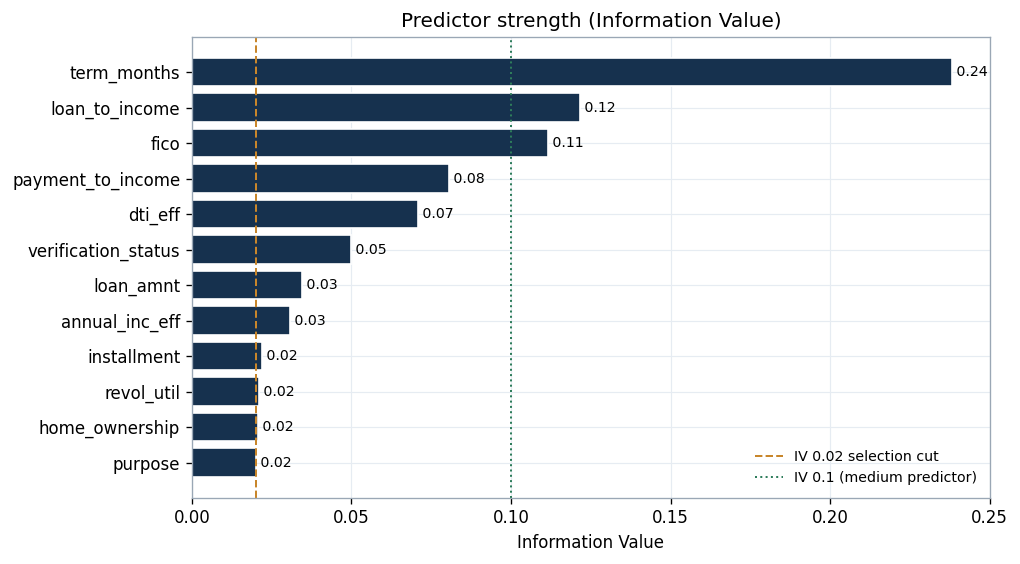

In [7]:
from IPython.display import Image
Image(filename="figures/01_information_value.png")

**WoE and bad rate by FICO bin**

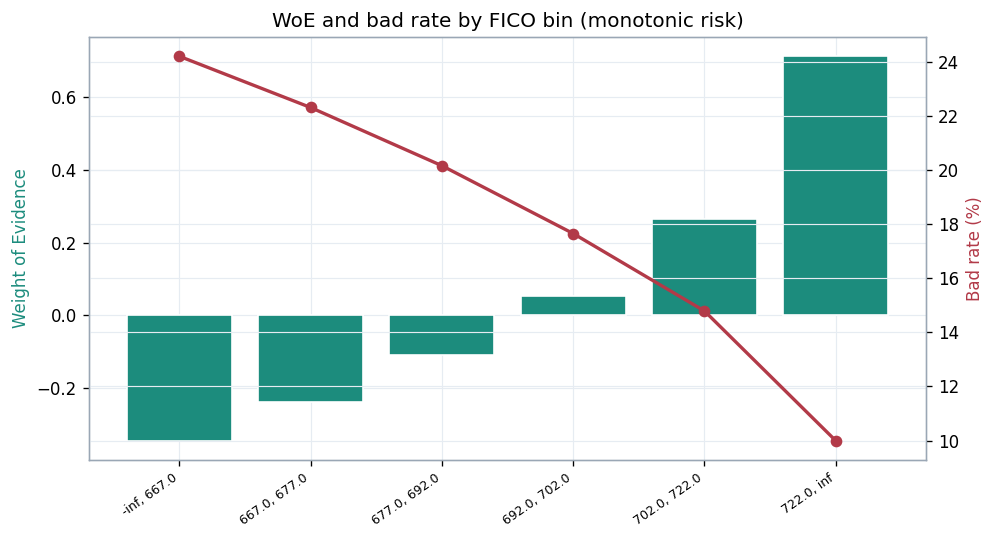

In [8]:
from IPython.display import Image
Image(filename="figures/02_woe_fico.png")

**Default rate by score band**

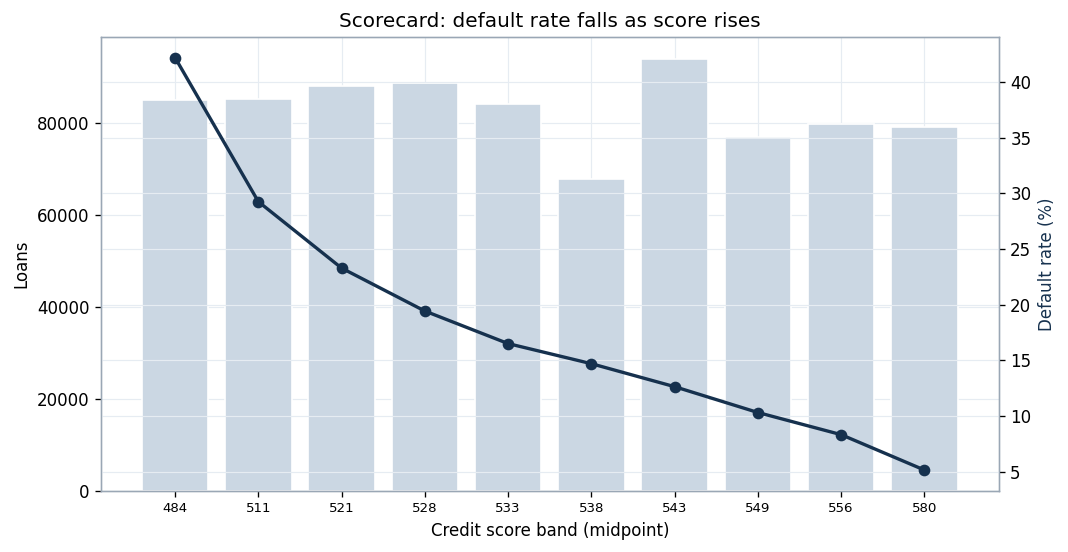

In [9]:
from IPython.display import Image
Image(filename="figures/03_score_distribution.png")

**Calibration on the out-of-time sample**

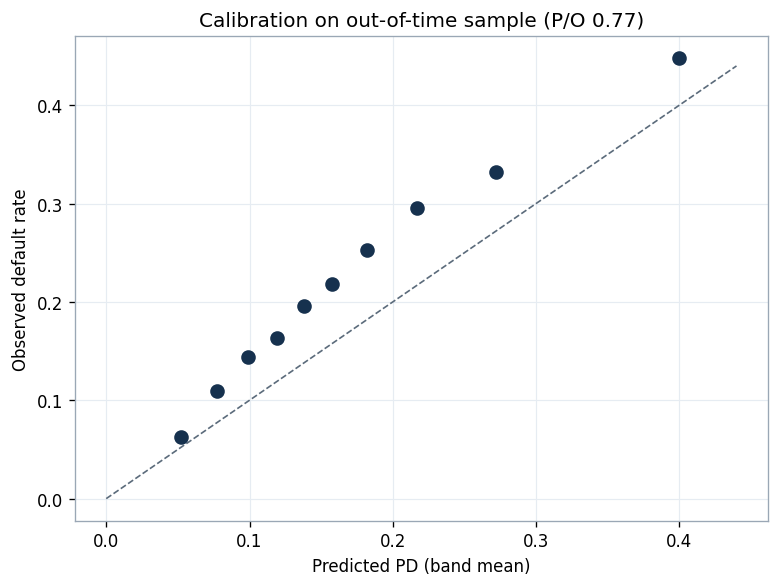

In [10]:
from IPython.display import Image
Image(filename="figures/04_calibration.png")

**Population stability: development vs out-of-time**

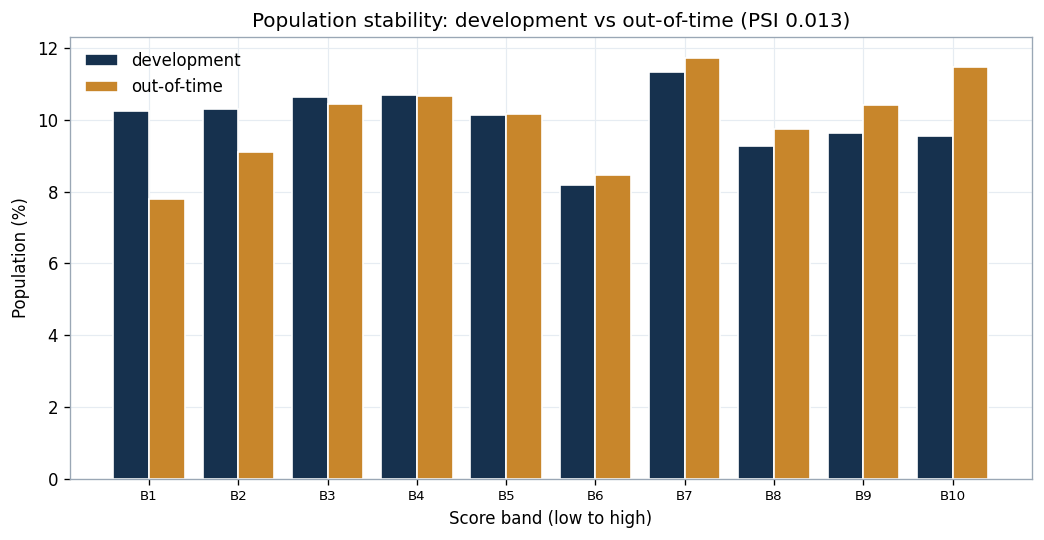

In [11]:
from IPython.display import Image
Image(filename="figures/05_psi.png")

**Effective challenge: scorecard vs challenger**

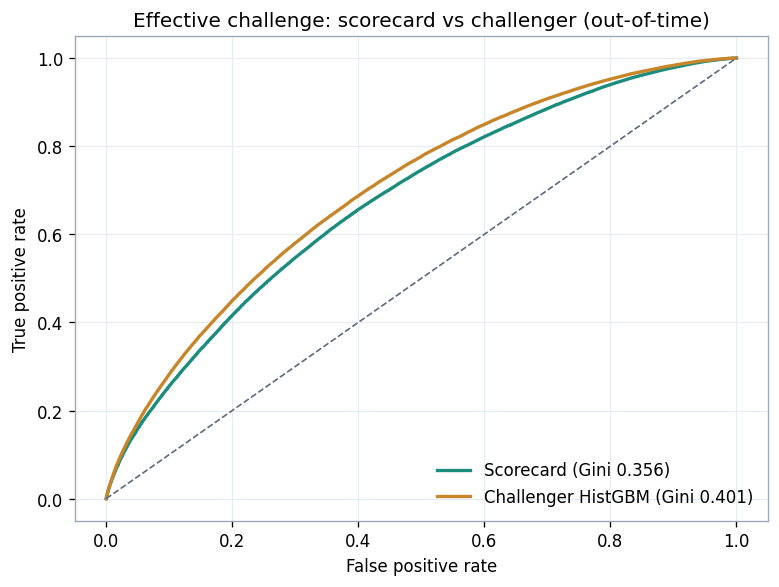

In [12]:
from IPython.display import Image
Image(filename="figures/06_benchmark_roc.png")

**Discrimination by segment**

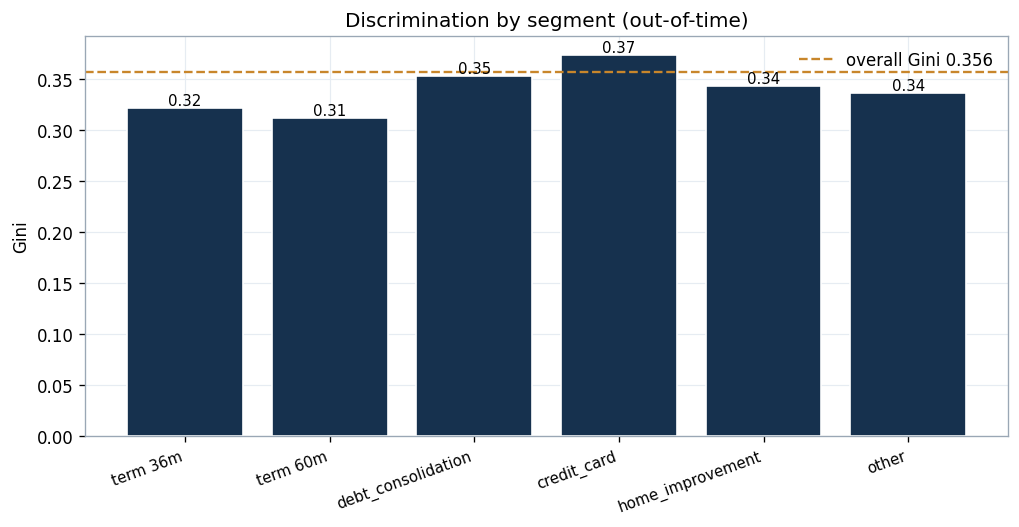

In [13]:
from IPython.display import Image
Image(filename="figures/07_segment_gini.png")